https://judge.nitro-ai.org/competitions/nitro-2025/nitro-warmup-round/1/view

# setup + imports

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error

In [ ]:
train_data = pd.read_csv('/content/train_data.csv')
test_data = pd.read_csv('/content/test_data.csv')

In [ ]:
y = train_data.Price
X = train_data.drop(['Price'], axis=1)

# subtask 1

In [ ]:
answers1 = []

for e in test_data['Estimated owners']:
  mini, maxi = e.split('-')
  mini = int(mini)
  maxi = int(maxi)
  answers1.append(int((mini+maxi)/2))

subtask1 = pd.DataFrame({
    "subtaskID": 1,
    "datapointID": test_data["AppID"],
    "answer": answers1
})


# data exploration

DATA CLEANING

Name- drop
AppID - pastram aparent?
Metacritic score
Genres
Publishers
Estimated Owners: de forma min – max
Negatives: numărul de dislike-uri
Positives: numărul de like-uri
nr Recommendations

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   AppID             3000 non-null   int64  
 1   Name              3000 non-null   object 
 2   Release date      3000 non-null   object 
 3   Estimated owners  3000 non-null   object 
 4   Price             3000 non-null   float64
 5   Metacritic score  3000 non-null   int64  
 6   Recommendations   3000 non-null   int64  
 7   Positive          3000 non-null   int64  
 8   Negative          3000 non-null   int64  
 9   Publishers        3000 non-null   object 
 10  Genres            3000 non-null   object 
dtypes: float64(1), int64(5), object(5)
memory usage: 257.9+ KB


In [ ]:
print(train_data.isna().sum().sum(), test_data.isna().sum().sum())
print("duplicate rows:", train_data.duplicated().sum())
train_data.nunique()

0 0
duplicate rows: 0


,0
AppID,3000
Name,2972
Release date,1871
Estimated owners,12
Price,113
Metacritic score,70
Recommendations,1870
Positive,2034
Negative,1199
Publishers,1291


In [ ]:
print(train_data.describe())
print((train_data == 0).sum())
train_data[train_data["Estimated owners"] == "0 - 0"]

              AppID        Price  Metacritic score  Recommendations  \
count  3.000000e+03  3000.000000        3000.00000      3000.000000   
mean   4.920876e+05    16.350767          72.83100      7666.167333   
std    4.314128e+05    11.476353          10.54575     29429.027434   
min    1.000000e+01     0.530000          20.00000         0.000000   
25%    2.246900e+05     9.990000          67.00000       199.250000   
50%    3.594500e+05    14.990000          74.00000       819.500000   
75%    6.996950e+05    19.990000          80.00000      3750.250000   
max    2.742010e+06    69.990000          97.00000    783469.000000   

            Positive       Negative  
count    3000.000000    3000.000000  
mean     8823.807000    1095.512333  
std     35028.920753    4211.014155  
min         0.000000       0.000000  
25%       212.000000      58.000000  
50%       879.000000     182.500000  
75%      4144.750000     625.000000  
max    964983.000000  129925.000000  
AppID             

,AppID,Name,Release date,Estimated owners,Price,Metacritic score,Recommendations,Positive,Negative,Publishers,Genres
457,227020,Rise of Venice,"September 27, 2013",0 - 0,19.99,66,295,0,0,Kalypso Media Digital,"Simulation,Strategy"
788,240660,Rain Blood Chronicles: Mirage,"November 11, 2013",0 - 0,4.99,68,130,0,0,Origo Games,"Action,Adventure,Indie"
833,253940,Septerra Core,"September 27, 2013",0 - 0,4.99,72,454,0,0,Topware Interactive,RPG
1276,2742010,Off-Road: Redneck Racing,"February 12, 2024",0 - 0,6.79,65,0,0,0,"Funbox Media Ltd,ZOOM Platform Media","Action,Racing"
1350,315260,Space Hack,"August 05, 2014",0 - 0,4.99,63,201,0,0,Meridian4,"Action,Indie,RPG"
1428,242550,Rayman® Legends,"September 03, 2013",0 - 0,29.99,89,5320,0,0,Ubisoft,"Action,Adventure"
1430,254100,World War II: Panzer Claws,"September 27, 2013",0 - 0,1.24,61,109,0,0,Topware Interactive,Strategy
1459,247910,Sniper Elite: Nazi Zombie Army 2,"October 31, 2013",0 - 0,14.99,53,2845,0,0,Rebellion,"Action,Adventure"
1619,242940,Anachronox,"October 17, 2013",0 - 0,6.99,77,329,0,0,Square Enix,RPG


Price
9.99     594
19.99    550
14.99    411
4.99     210
29.99    191
24.99    128
39.99     88
7.99      67
5.99      62
59.99     62
Name: count, dtype: int64


<Axes: >

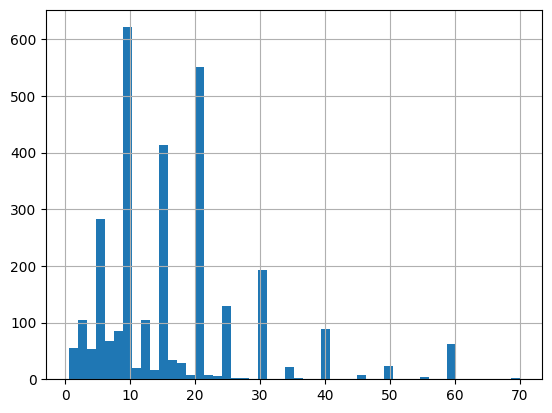

In [ ]:
print(train_data["Price"].value_counts().head(10))
train_data["Price"].hist(bins=50)

In [ ]:
train_data.select_dtypes("number").corr(method="spearman")["Price"].sort_values()

,Price
Metacritic score,0.243081
Negative,0.299691
Positive,0.336410
AppID,0.341189
Recommendations,0.356798
Price,1.000000


In [ ]:
train_data.groupby("Estimated owners")["Price"].agg(["count", "median"])
exploded = train_data.assign(Genre=train_data["Genres"].str.split(",")).explode("Genre")
exploded.groupby("Genre")["Price"].agg(["count", "median"])

,count,median
Genre,,
Action,1512,14.99
Adventure,1326,14.99
Casual,383,9.99
Early Access,3,4.99
Free to Play,2,27.49
Gore,2,5.89
Indie,1700,14.99
Massively Multiplayer,22,19.99
Nudity,3,12.99


# cleaning function


In [ ]:
genre_counts = {}
for e in train_data['Genres']:
  for g in e.split(','):
    if g not in genre_counts:
      genre_counts[g] = 1
    else:
      genre_counts[g] += 1

common_genres = []
for g in genre_counts.keys():
  if genre_counts[g] > 10:
    common_genres.append(g)

In [ ]:
def clean_input(data, common_genres):
  data = data.copy()

  data = data.drop(columns='Name')
  data = data.drop(columns='Publishers')

  data['Total'] = data['Positive'] + data['Negative']
  data['Ratio'] = (data['Positive']+1) / (data['Positive']+data['Negative']+2)


  answers = []
  for e in data['Estimated owners']:
    mini, maxi = e.split('-')
    mini = int(mini)
    maxi = int(maxi)
    mid = int((mini + maxi) / 2)
    if mid == 0:
      mid = np.nan
    answers.append(mid)
  data['Estimated owners'] = answers


  years = []
  for e in data['Release date']:
    month_day, year = e.split(',')
    years.append(int(year))
  data['Year'] = years
  data = data.drop(columns='Release date')


  for g in common_genres:
    column = []
    for e in data['Genres']:
      if g in e.split(','):
        column.append(1)
      else:
        column.append(0)
    data['Genre ' + g] = column
  data = data.drop(columns='Genres')

  return data


In [ ]:
X_clean = clean_input(X, common_genres)
test_clean = clean_input(test_data, common_genres)

print(X_clean.dtypes)
print(list(X_clean.columns) == list(test_clean.columns))

AppID                            int64
Estimated owners               float64
Metacritic score                 int64
Recommendations                  int64
Positive                         int64
Negative                         int64
Total                            int64
Ratio                          float64
Year                             int64
Genre Simulation                 int64
Genre Strategy                   int64
Genre Action                     int64
Genre Adventure                  int64
Genre Casual                     int64
Genre Indie                      int64
Genre Sports                     int64
Genre RPG                        int64
Genre Massively Multiplayer      int64
Genre Racing                     int64
dtype: object
True


# model + validare

In [ ]:
def eval(model, X_clean, y):
  kf = KFold(n_splits=5, shuffle=True, random_state=0)
  scores = []
  for fitrows, valrows in kf.split(X_clean):
    X_fit = X_clean.iloc[fitrows]
    y_fit = y.iloc[fitrows]
    X_val = X_clean.iloc[valrows]
    y_val = y.iloc[valrows]

    model.fit(X_fit, y_fit)
    preds = model.predict(X_val)
    score = mean_absolute_error(y_val, preds)
    scores.append(score)

  print('fold scores:', [round(s, 2) for s in scores])
  print('mean:', round(np.mean(scores), 3), ' spread:', round(np.std(scores), 3))

In [ ]:
eval(DummyRegressor(strategy='median'), X_clean, y)

fold scores: [7.97, 8.25, 8.65, 7.64, 7.85]
mean: 8.072  spread: 0.349


In [ ]:
eval(HistGradientBoostingRegressor(loss='absolute_error', random_state=0), X_clean, y)

fold scores: [6.5, 6.25, 6.38, 5.92, 5.9]
mean: 6.19  spread: 0.244


#prediction

In [ ]:
model = HistGradientBoostingRegressor(loss='absolute_error', random_state=0)
model.fit(X_clean, y)
preds = model.predict(test_clean)
print('mean:', round(np.mean(preds), 3))

mean: 15.614


In [ ]:
maxdist = 0.5

rounded = []
for p in preds:
  target = round(p) - 0.01
  if target < 0.99:
    target = 0.99
  if abs(target - p) <= maxdist:
    rounded.append(target)
  else:
    rounded.append(p)
preds = rounded
print('mean:', round(np.mean(preds), 3))

mean: 15.595


In [ ]:
subtask2 = pd.DataFrame({
    "subtaskID": 2,
    "datapointID": test_data["AppID"],
    "answer": preds
})

In [ ]:
submission = pd.concat([subtask1, subtask2], ignore_index=True)
submission.to_csv('submission.csv', index=False)